# Project 1: House Sales in King County, USA

### Importing the libraries
 Importing the libraries is the first most import steps when building a ML models since the libraries will ease our work and also make the model training more faster

 In this section I imported some ML Libraries which perform different roles Ranging from Libraries used for Scientific computing, Data visualization to Machine Learning algorithms.

### Libraries and their uses:
- Pandas: Data manipulation and Data analysis
- numpy: Used for perfoming operation on numerical data
- matplotlib: For data visualization
- seaborn: for data visualization 


In [50]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import dash
from dash import dcc, html
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
%matplotlib inline

In [52]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [70]:
house_data = pd.read_csv("kc_house_data.csv")
house_data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [55]:
house_data[['condition', 'waterfront']]

,condition,waterfront
0,3,0
1,3,0
2,3,0
3,5,0
4,3,0
...,...,...
21608,3,0
21609,3,0
21610,3,0
21611,3,0


In [56]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [57]:
house_data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [61]:
columns = [col for col in house_data.columns ]

for col in columns:
    print(house_data[col].value_counts(),"\n")

id
795000620     3
8651510380    2
2568300045    2
9353300600    2
4139480200    2
             ..
2767603649    1
1446403617    1
5602000275    1
1786200010    1
1523300157    1
Name: count, Length: 21436, dtype: int64 

date
20140623T000000    142
20140626T000000    131
20140625T000000    131
20140708T000000    127
20150427T000000    126
                  ... 
20141102T000000      1
20150131T000000      1
20150524T000000      1
20140517T000000      1
20140727T000000      1
Name: count, Length: 372, dtype: int64 

price
350000.0     172
450000.0     172
550000.0     159
500000.0     152
425000.0     150
            ... 
607010.0       1
1362500.0      1
298800.0       1
957500.0       1
402101.0       1
Name: count, Length: 4028, dtype: int64 

bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
0       13
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64 

bathrooms
2.50    5380
1.00    3852
1.75    3048
2.25    2047
2.

In [15]:
house_data.bedrooms.describe()

count    21613.000000
mean         3.370842
std          0.930062
min          0.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         33.000000
Name: bedrooms, dtype: float64

In [17]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

### Visualization Of Data To Gain Insight

I classified the data into 2 types 
- categorical
- Numerical/continous

The categorical Data includes Bedrooms, floors, waterfront, condition, grade, and zipcode. All this value are not continuous.
In this category of the dataset I use histogram to visualize the data.


The other category is the numerical data's which Includes 

In [20]:
house_data.nunique()

id               21436
date               372
price             4028
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
dtype: int64

In [22]:
categorical_features = ['bedrooms', 'floors', 'waterfront', 'view', 'condition', 'grade', 'zipcode']
plot_type = 'hist'
df = house_data

In [24]:
# App setup
app = dash.Dash(__name__)
app.title = "Interactive Plotly Grid"

In [26]:
def generate_plot(feature, plot_type='hist'):
    if plot_type == 'hist':
        fig = px.histogram(df, x=feature, nbins=30, marginal='box', title=f'Histogram of {feature}')
    elif plot_type == 'scatter':
        fig = px.scatter(df, x=df.index, y=feature, title=f'Scatter Plot of {feature}')
    elif plot_type == 'box':
        fig = px.box(df, y=feature, title=f'Box Plot of {feature}')
    else:
        raise ValueError(f"Unsupported plot type: {plot_type}")
    
    fig.update_layout(
        title_font_size=18,
        template='plotly_white',
        height=350,
        margin=dict(l=30, r=30, t=40, b=30)
    )
    return fig

# Layout
app.layout = html.Div([
    html.H1("Feature Visualizations", style={'textAlign': 'center'}),
    html.Div([
        html.Div([
            dcc.Graph(figure=generate_plot(feature, plot_type))
        ], className='four columns') for feature in categorical_features
    ], className='row', style={'display': 'flex', 'flexWrap': 'wrap', 'gap': '20px', 'justifyContent': 'center'})
], style={'padding': '20px'})




In [28]:
# Run server
if __name__ == '__main__':
    app.run(debug=True)

In [64]:
house_data['lot_living_ratio'] = house_data['sqft_lot'] / house_data['sqft_living']
print(house_data[['lot_living_ratio', 'price']].corr())


                  lot_living_ratio     price
lot_living_ratio          1.000000 -0.023094
price                    -0.023094  1.000000


In [66]:
house_data['log_sqft_lot'] = np.log1p(house_data['sqft_lot'])
print(house_data[['log_sqft_lot', 'price']].corr())


              log_sqft_lot     price
log_sqft_lot      1.000000  0.161322
price             0.161322  1.000000


In [34]:
house_data['house_age'] = 2016 - house_data['yr_built']

house_data['years_since_renovation'] = np.where(
    house_data['yr_renovated'] > 0,  # If the house was renovated
    2016 - house_data['yr_renovated'],  # Calculate years since last renovation
    house_data['house_age']  # If never renovated, use house age
)

house_data['was_renovated'] = (house_data['yr_renovated'] > 0).astype(int)

house_data['effective_age'] = np.where(
    house_data['was_renovated'] == 1,
    house_data['years_since_renovation'],  # If renovated, use years since renovation
    house_data['house_age']  # If not, use full house age
)


print(house_data[['house_age', 'years_since_renovation', 'was_renovated', 'effective_age', 'price']].corr())



                        house_age  years_since_renovation  was_renovated  \
house_age                1.000000                0.909924       0.225195   
years_since_renovation   0.909924                1.000000      -0.163703   
was_renovated            0.225195               -0.163703       1.000000   
effective_age            0.909924                1.000000      -0.163703   
price                   -0.054012               -0.105755       0.126092   

                        effective_age     price  
house_age                    0.909924 -0.054012  
years_since_renovation       1.000000 -0.105755  
was_renovated               -0.163703  0.126092  
effective_age                1.000000 -0.105755  
price                       -0.105755  1.000000  


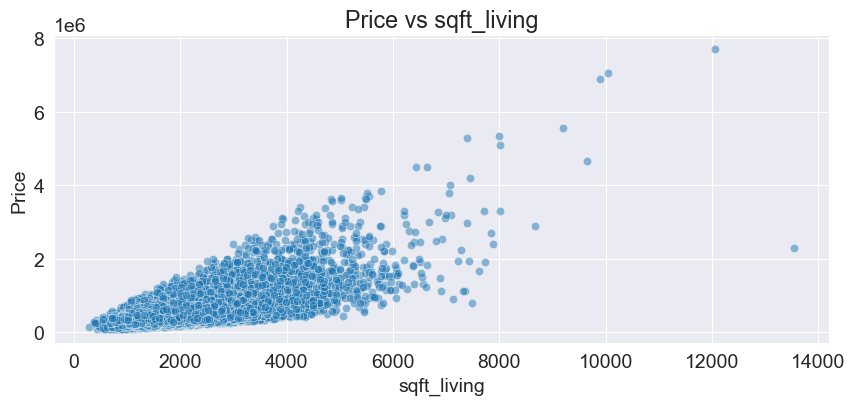

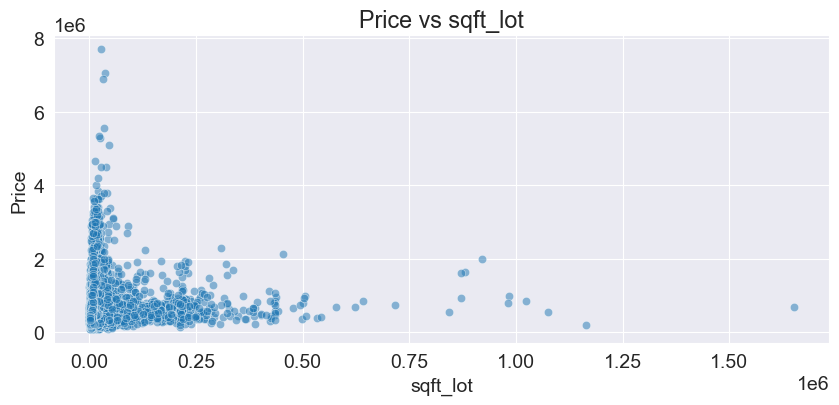

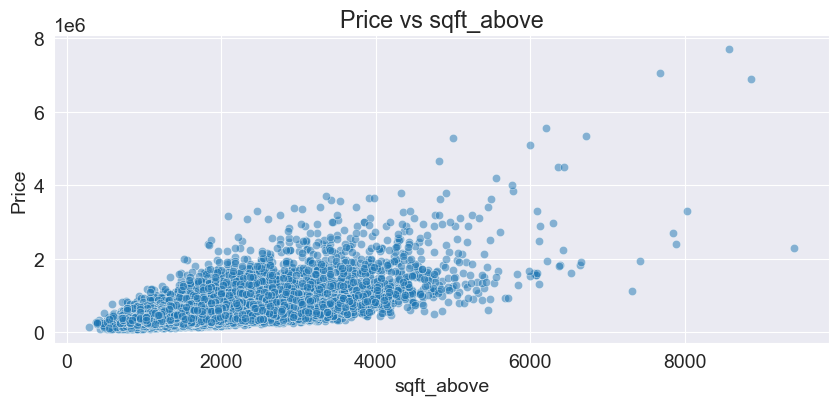

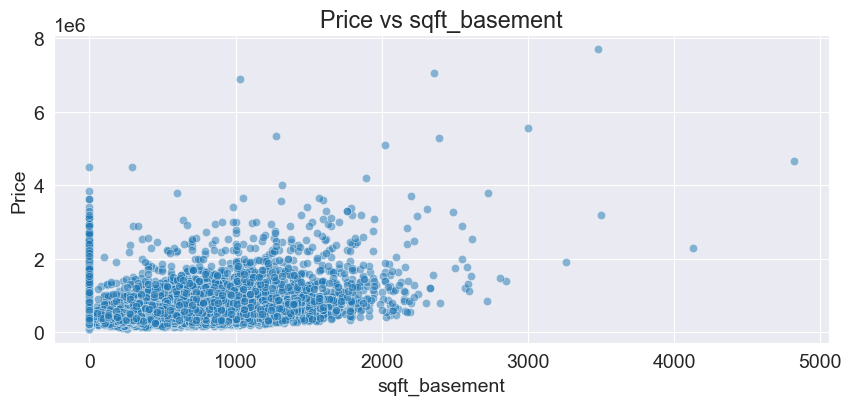

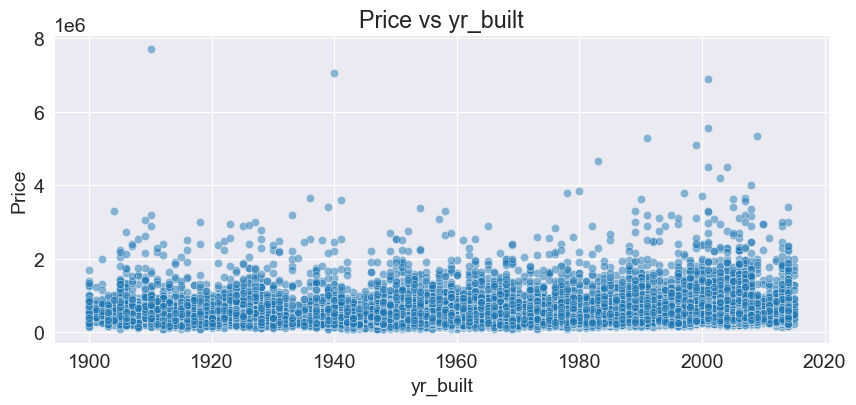

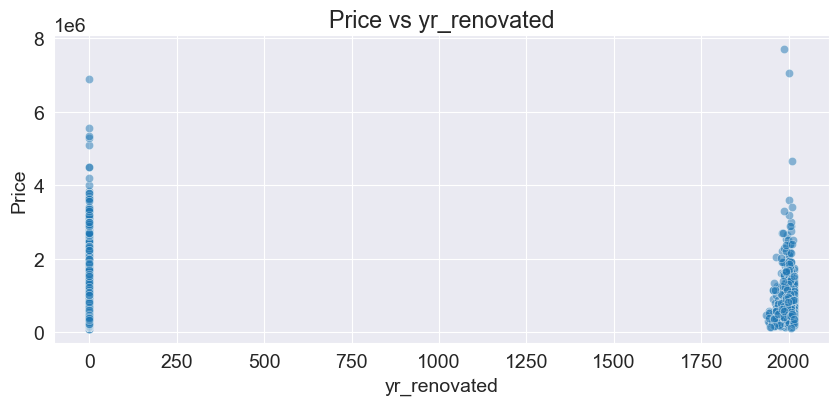

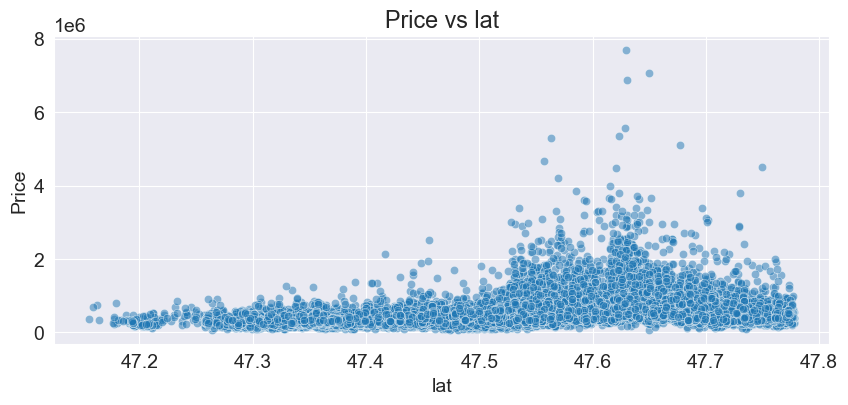

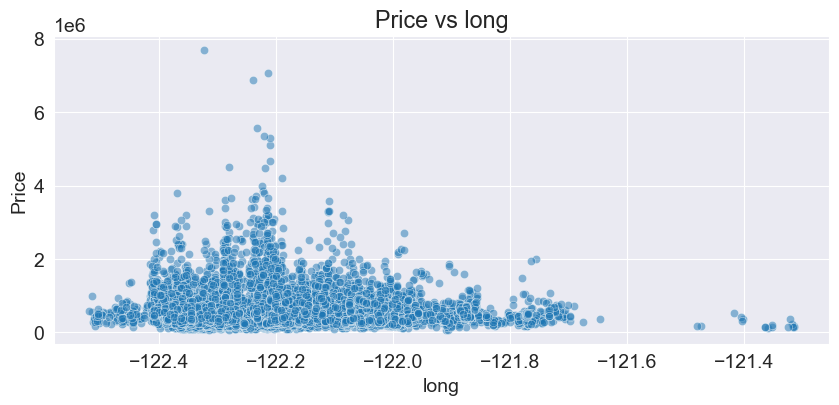

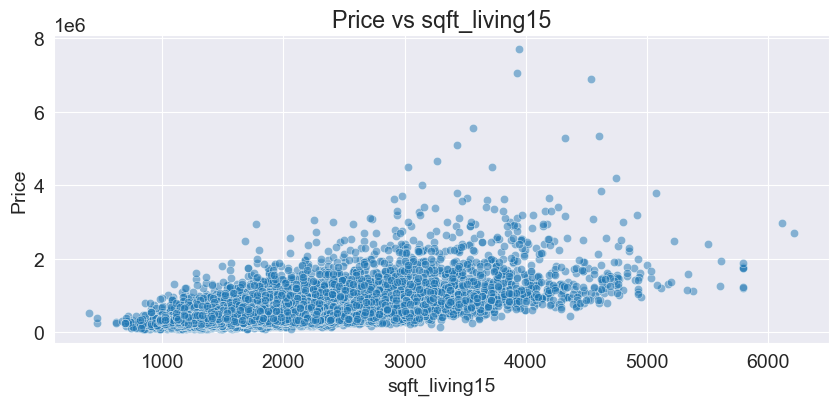

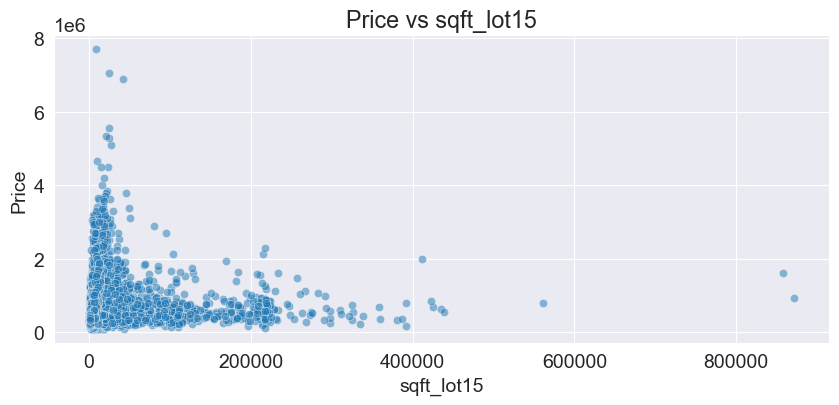

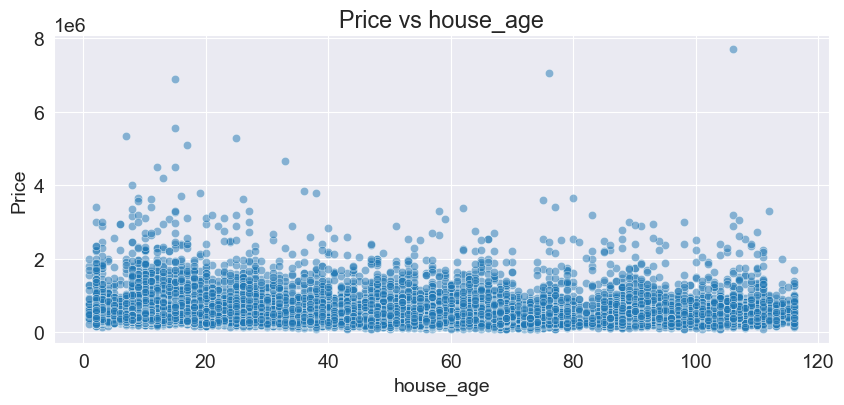

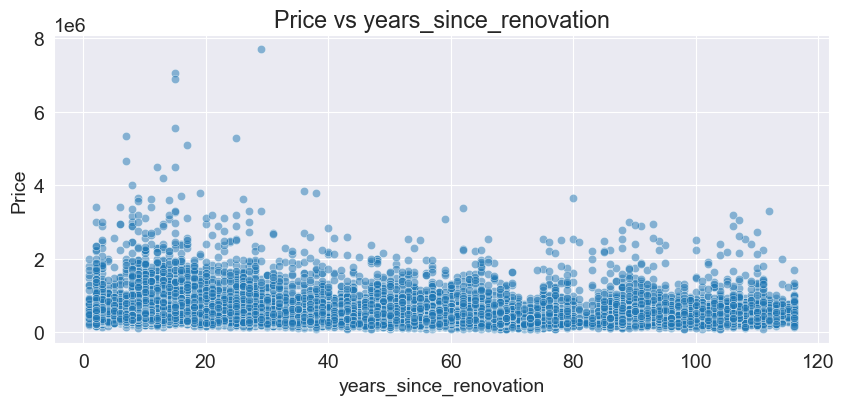

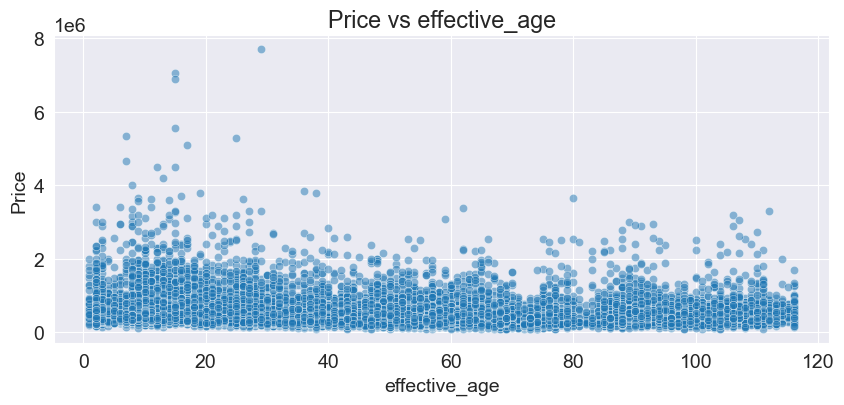

In [35]:
continous_features = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 
                      'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'years_since_renovation', 'effective_age']

for feature in continous_features:
    plt.figure(figsize=(10, 4))
    sns.scatterplot(x=house_data[feature], y=house_data['price'], alpha=0.5)
    plt.title(f'Price vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.show()


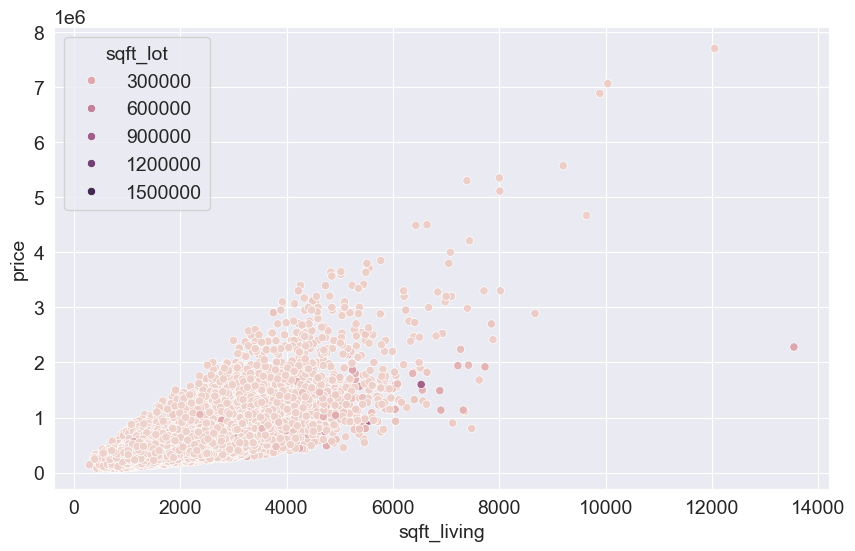

In [36]:
sns.scatterplot(x=house_data['sqft_living'], y=house_data['price'], hue=house_data['sqft_lot'])
plt.show()


In [38]:
house_data['date'] = house_data['date'].str.split('T').str[0]  
house_data['date'] = pd.to_datetime(house_data['date'], format='%Y%m%d')  


house_data['year'] = house_data['date'].dt.year
house_data['month'] = house_data['date'].dt.month
house_data['day'] = house_data['date'].dt.day

house_data = house_data.drop("date", axis=1)
house_data.head()


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_lot15,lot_living_ratio,log_sqft_lot,house_age,years_since_renovation,was_renovated,effective_age,year,month,day
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,5650,4.788136,8.639588,61,61,0,61,2014,10,13
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,7639,2.817899,8.887791,65,25,1,25,2014,12,9
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,8062,12.987013,9.210440,83,83,0,83,2015,2,25
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,5000,2.551020,8.517393,51,51,0,51,2014,12,9
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,7503,4.809524,8.997271,29,29,0,29,2015,2,18


In [39]:
house_data.columns.values

array(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat',
       'long', 'sqft_living15', 'sqft_lot15', 'lot_living_ratio',
       'log_sqft_lot', 'house_age', 'years_since_renovation',
       'was_renovated', 'effective_age', 'year', 'month', 'day'],
      dtype=object)

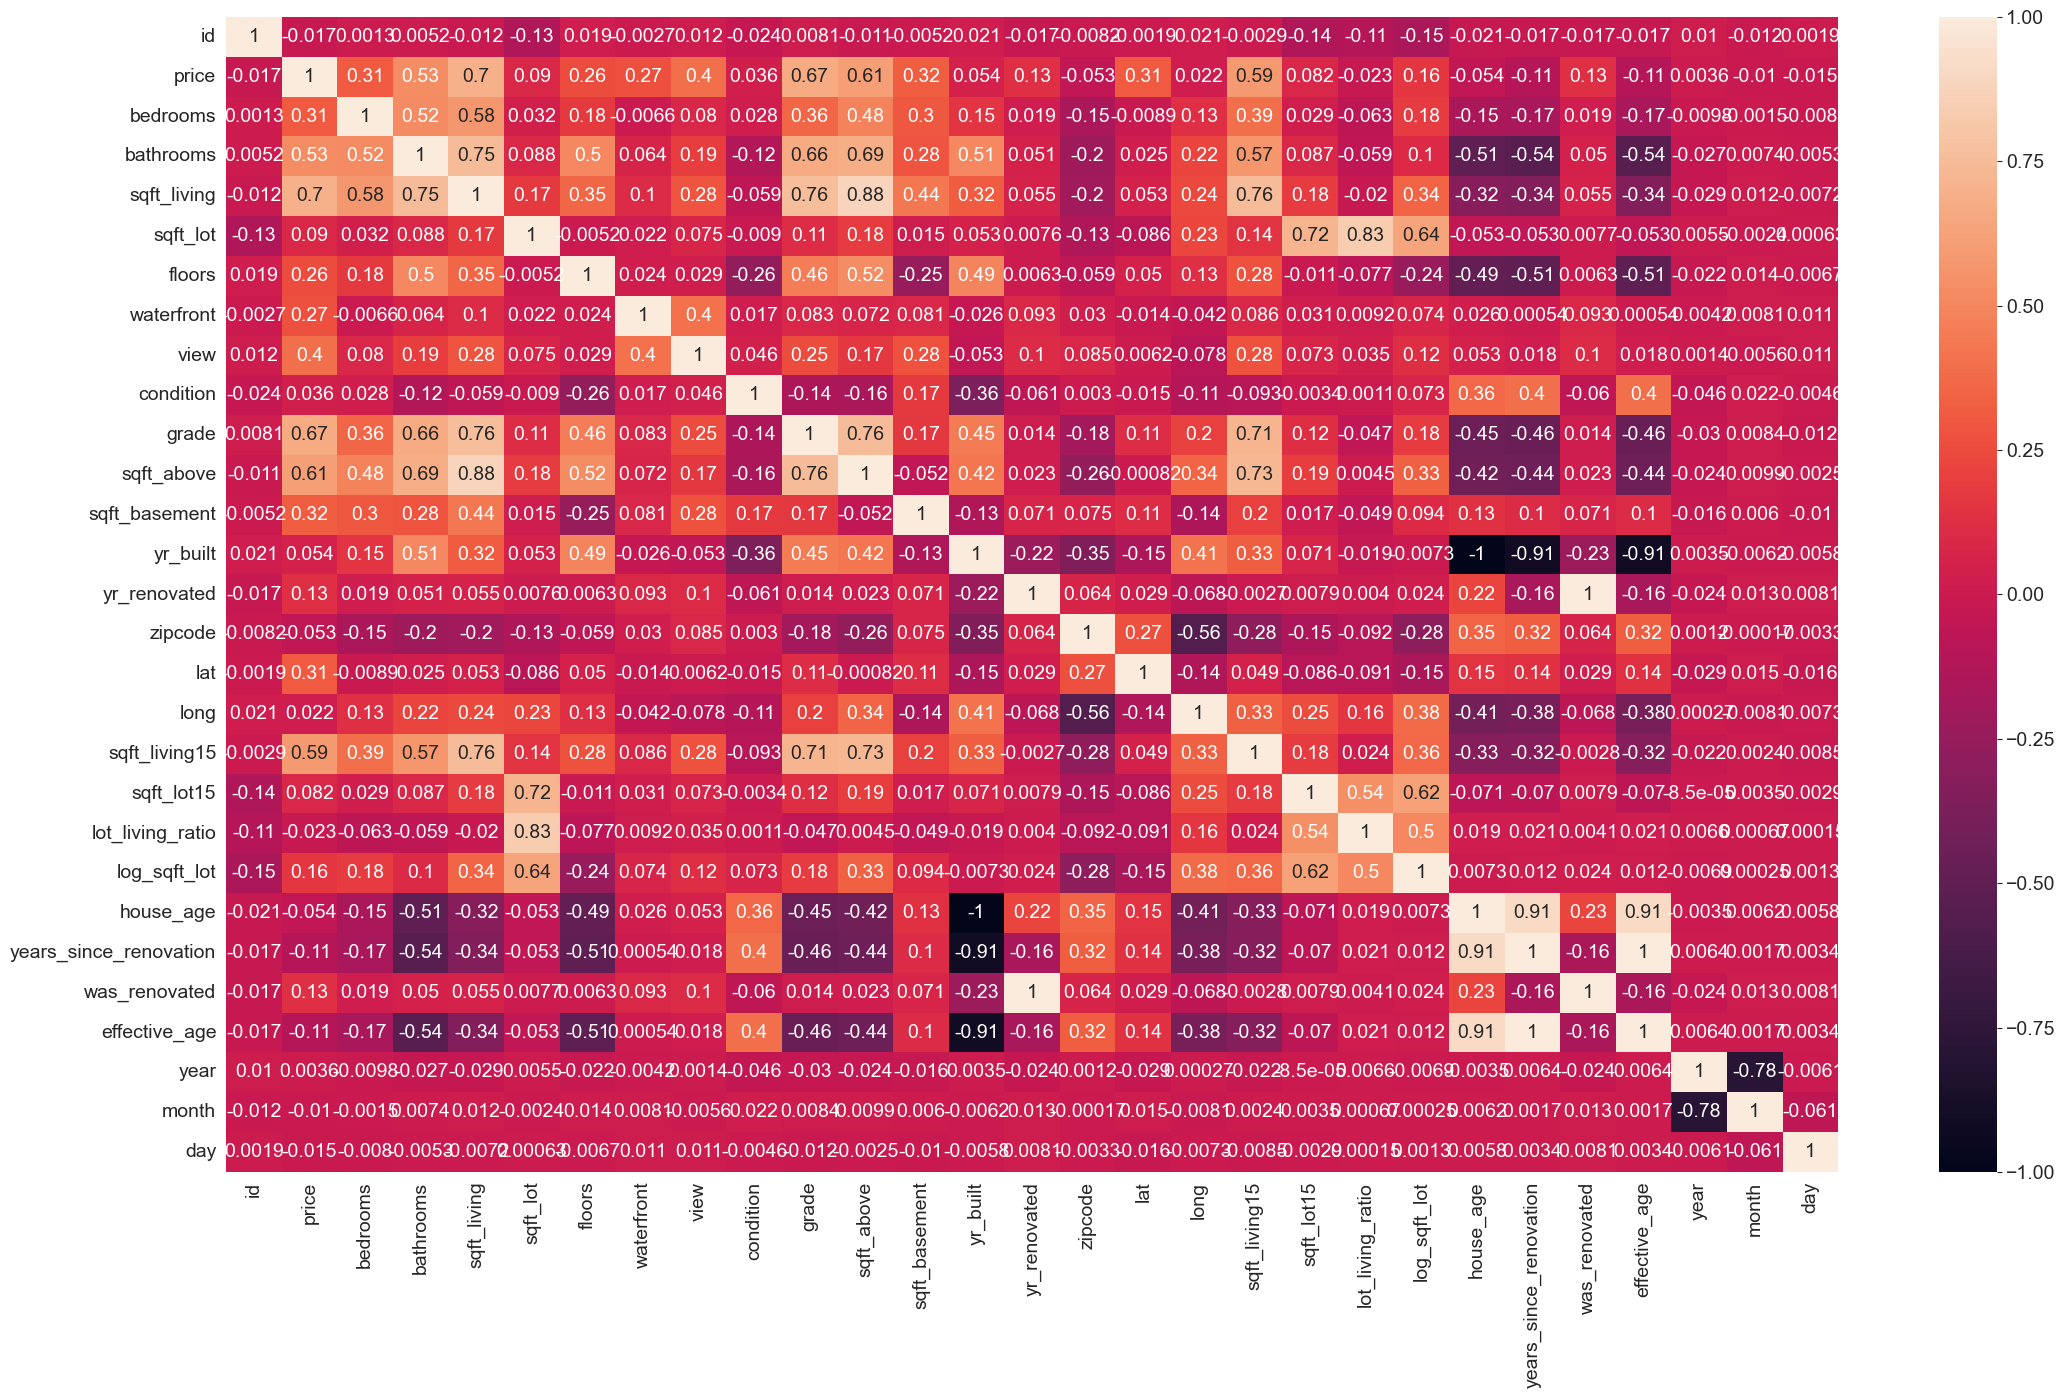

In [44]:
corr_map = house_data.corr()
plt.figure(figsize=(26,15))
sns.heatmap(corr_map, annot=True)
plt.show()

In [46]:
plt.figure?

Signature:
plt.figure(
    num: 'int | str | Figure | SubFigure | None' = None,
    figsize: 'tuple[float, float] | None' = None,
    dpi: 'float | None' = None,
    *,
    facecolor: 'ColorType | None' = None,
    edgecolor: 'ColorType | None' = None,
    frameon: 'bool' = True,
    FigureClass: 'type[Figure]' = <class 'matplotlib.figure.Figure'>,
    clear: 'bool' = False,
    **kwargs,
) -> 'Figure'
Docstring:
Create a new figure, or activate an existing figure.

Parameters
----------
num : int or str or `.Figure` or `.SubFigure`, optional
    A unique identifier for the figure.

    If a figure with that identifier already exists, this figure is made
    active and returned. An integer refers to the ``Figure.number``
    attribute, a string refers to the figure label.

    If there is no figure with the identifier or *num* is not given, a new
    figure is created, made active and returned.  If *num* is an int, it
    will be used for the ``Figure.number`` attribute, otherwise, an


In [68]:
train_set, test_set = train_test_split(house_data, test_size = 0.2, random_state = 42)

In [ ]:
def _encoding(train_data, test_data):
    
    encoder = BinaryEncoder(cols = ['CarName', 'enginetype', 'cylindernumber'])
    encoded_train_set = encoder.fit_transform(train_set)

    encoded_test_set = encoder.transform(test_set)

    return encoded_train_set, encoded_test_set

encoded_train, encoded_test = car_name_encoding(train_set, test_set)
encoded_train


In [ ]:
encoded_test

In [ ]:
new_df_dum.info()


In [ ]:
print(target)

In [ ]:
Scaler = StandardScaler()
new_df_dum = Scaler.fit_transform(new_df_dum)
new_df_dum

In [ ]:
target_scaler = StandardScaler()
target = target_scaler.fit_transform(target.values.reshape(-1, 1))

In [ ]:
target

## Training Data

In [ ]:

train_data, temp_data = train_test_split(new_df_dum, test_size=0.3, random_state=42)

val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)


print(f"Train set: {len(train_data)}")
print(f"Validation set: {len(val_data)}")
print(f"Test set: {len(test_data)}")


In [ ]:
train_data.shape

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(new_df_dum, target, test_size=0.3, random_state=42)


X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train set: Independent_features={X_train.shape}, Dependent_feature={y_train.shape}")
print(f"Validation set: Independent_features={X_val.shape}, Dependent_feature={y_val.shape}")
print(f"Test set: Independent_features={X_test.shape}, Dependent_feature={y_test.shape}")


In [ ]:
drop_cols = ['id', 'waterfront', 'long', 'lat', 'sqft_lot', 'condition', 'yr_built', 'zipcode', 'house_age', 'year', 'month', 'day']
new_df= new_df.drop(drop_cols, axis = 1)

In [ ]:
poly = PolynomialFeatures(degree=2) 
X_train_poly = poly.fit_transform(train_data)

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)  # Adjust alpha to control feature selection
lasso.fit(X_train_poly, y_train)
important_features = lasso.coef_ != 0  # Keep only non-zero coefficients
X_reduced = X_train_poly[:, important_features]


In [ ]:
model = LinearRegression(n_jobs = -1)
model.fit(X_train, y_train)

In [ ]:
predictions = model.predict(X_val)
#predicted = target_scaler.inverse_transform(predictions)

In [ ]:
y_val

In [ ]:
MSE = mean_squared_error(y_val, predictions)
MSE

In [ ]:
predictions

In [ ]:
r2 = r2_score(y_val, predictions)
r2

In [ ]:
predicted=model.predict(X_val)
predicted

In [ ]:
R2Score=r2_score(y_val, predicted)
print(f"R2Score {R2Score}")
mean_squared_error = mean_squared_error(y_test, predicted)
print(f"mean_squared_error {mean_squared_error}")
mean_absolute_error=mean_absolute_error(y_test, predicted)
print(f"mean_absolute_error {mean_absolute_error}")

In [ ]:
plt.scatter(y_test, predictions, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()